In [1]:
!pip install roboflow ultralytics torch torchvision torchaudio opencv-python matplotlib pyyaml pandas scikit-learn albumentations --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 142.9 MB/s eta 0:00:00


In [2]:
import os
import torch
import yaml
import numpy as np
import pandas as pd
from pathlib import Path
from roboflow import Roboflow
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import albumentations as A
import shutil
import random

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
ROBOFLOW_API_KEY = "xcDJdDJpIdytumuUX8pM"
WORKSPACE = "ppe-wqipw"
PROJECT = "ppe-detection-public"
VERSION = 2

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)

dataset = project.version(VERSION).download("yolov8")

DATA_DIR = Path(dataset.location)
print("✅ Dataset path:", DATA_DIR)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ppe-detection-public-2 in yolov8:: 100%|██████████| 3361/3361 [00:00<00:00, 3589.07it/s]


✅ Dataset path: /content/ppe-detection-public-2


Original Train samples: 1383


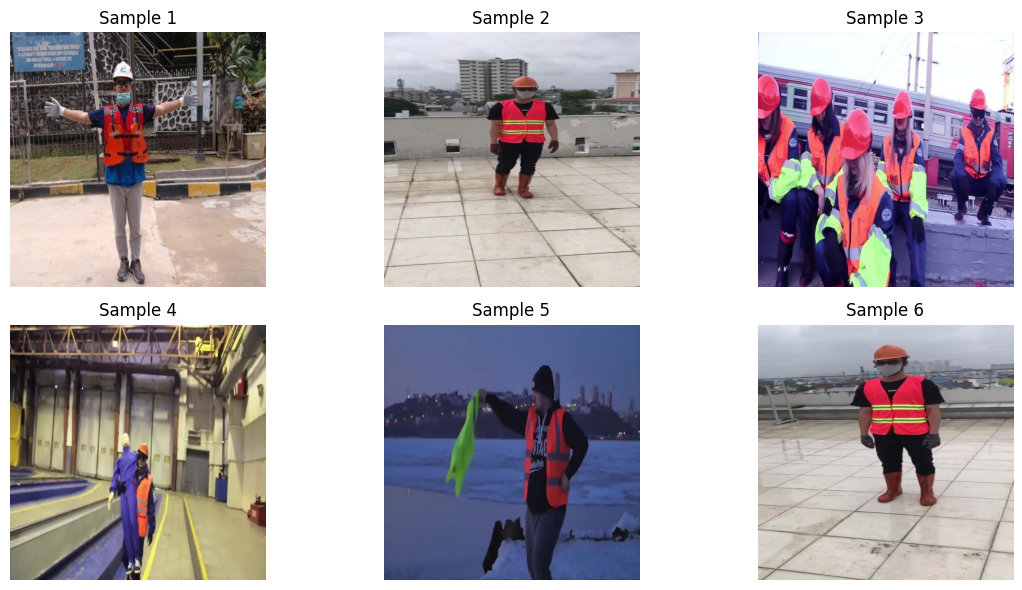

In [5]:
image_paths = list((DATA_DIR / "train" / "images").glob("*.jpg"))
print("Original Train samples:", len(image_paths))

# sample = cv2.imread(str(image_paths[0]))
# plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
# plt.title("Sample Training Image")
# plt.axis("off")
# plt.show()

random_images = random.sample(image_paths, 6)

plt.figure(figsize=(12, 6))

for i, img_path in enumerate(random_images):
    sample = cv2.imread(str(img_path))
    sample = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(sample)
    plt.title(f"Sample {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=15, p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def apply_augmentation(image_path, bboxes, labels):
    image = cv2.imread(str(image_path))
    augmented = train_transform(image=image, bboxes=bboxes, class_labels=labels)
    return augmented['image'], augmented['bboxes'], augmented['class_labels']

ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.


In [7]:
AUG_TRAIN_DIR = DATA_DIR / "train_aug"
(AUG_TRAIN_DIR / "images").mkdir(parents=True, exist_ok=True)
(AUG_TRAIN_DIR / "labels").mkdir(parents=True, exist_ok=True)

num_aug_per_image = 3

for img_path in image_paths:
    base_name = img_path.stem

    shutil.copy(img_path, AUG_TRAIN_DIR / "images" / f"{base_name}.jpg")
    lbl_path = DATA_DIR / "train" / "labels" / f"{base_name}.txt"
    shutil.copy(lbl_path, AUG_TRAIN_DIR / "labels" / f"{base_name}.txt")


    bboxes, labels = [], []
    with open(lbl_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            labels.append(int(parts[0]))
            bboxes.append([float(x) for x in parts[1:]])


    for i in range(num_aug_per_image):
        aug_image, aug_bboxes, aug_labels = apply_augmentation(img_path, bboxes, labels)
        new_name = f"{base_name}_aug{i+1}.jpg"
        cv2.imwrite(str(AUG_TRAIN_DIR / "images" / new_name), aug_image)

        with open(AUG_TRAIN_DIR / "labels" / f"{base_name}_aug{i+1}.txt", 'w') as f:
            for cls, bbox in zip(aug_labels, aug_bboxes):
                f.write(f"{cls} {' '.join([str(x) for x in bbox])}\n")


aug_image_paths = list((AUG_TRAIN_DIR / "images").glob("*.jpg"))
print("✅ Number of training images after augmentation:", len(aug_image_paths))

✅ Number of training images after augmentation: 5532


In [8]:
model = YOLO("yolo11n.pt")


results = model.train(
    data=str(DATA_DIR / "data.yaml"),
    epochs=40,
    imgsz=640,
    batch=16,
    name="ppe_yolo11_aug",
    device=0 if torch.cuda.is_available() else "cpu",
)

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe-detection-public-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_yolo11_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspecti

In [9]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 735.0±217.6 MB/s, size: 48.2 KB)
val: Scanning /content/ppe-detection-public-2/valid/labels.cache... 293 images, 50 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 293/293 87.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.4it/s 4.4s
                   all        293       1299      0.946      0.959      0.975      0.761
                Gloves        161        302       0.99      0.955      0.989       0.67
                Helmet        180        188      0.963      0.975       0.99      0.735
                Person        162        170      0.865      0.965      0.959      0.834
                 Shoes        170        336      0.963      0.979      0.991       0.77
                  Vest        232

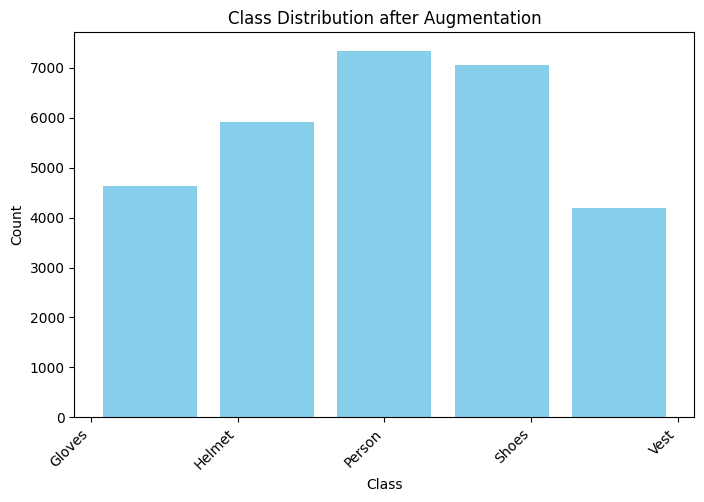

In [10]:
with open(DATA_DIR / "data.yaml") as f:
    data_cfg = yaml.safe_load(f)
class_names = data_cfg['names']

all_labels = []

for lbl_file in (AUG_TRAIN_DIR / "labels").glob("*.txt"):
    with open(lbl_file, 'r') as f:
        for l in f.readlines():

            cls = int(float(l.strip().split()[0]))
            all_labels.append(class_names[cls])

plt.figure(figsize=(8,5))
plt.hist(all_labels, bins=len(class_names), rwidth=0.8, color='skyblue')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.title("Class Distribution after Augmentation")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()



image 1/1 //content/full-body-portrait-image-black-260nw-2686272785.webp: 640x608 1 Gloves, 1 Helmet, 1 Person, 2 Shoess, 1 Vest, 54.2ms
Speed: 2.7ms preprocess, 54.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 608)


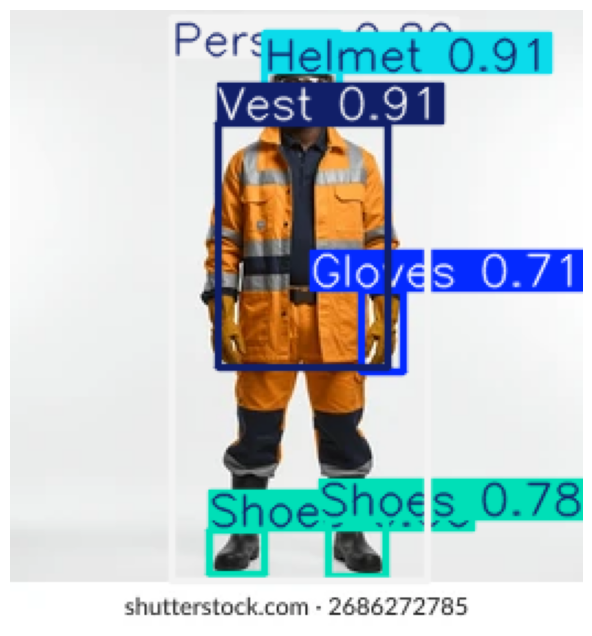

In [11]:
test_image_path = "//content/full-body-portrait-image-black-260nw-2686272785.webp"

results = model.predict(test_image_path, imgsz=640, conf=0.50)

for r in results:

    annotated_frame = r.plot()
    plt.figure(figsize=(10,8))
    plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


image 1/1 /content/subang-18-march-2025-group-260nw-2649583207.webp: 544x640 7 Helmets, 11 Persons, 14 Shoess, 11 Vests, 50.9ms
Speed: 2.1ms preprocess, 50.9ms inference, 1.4ms postprocess per image at shape (1, 3, 544, 640)


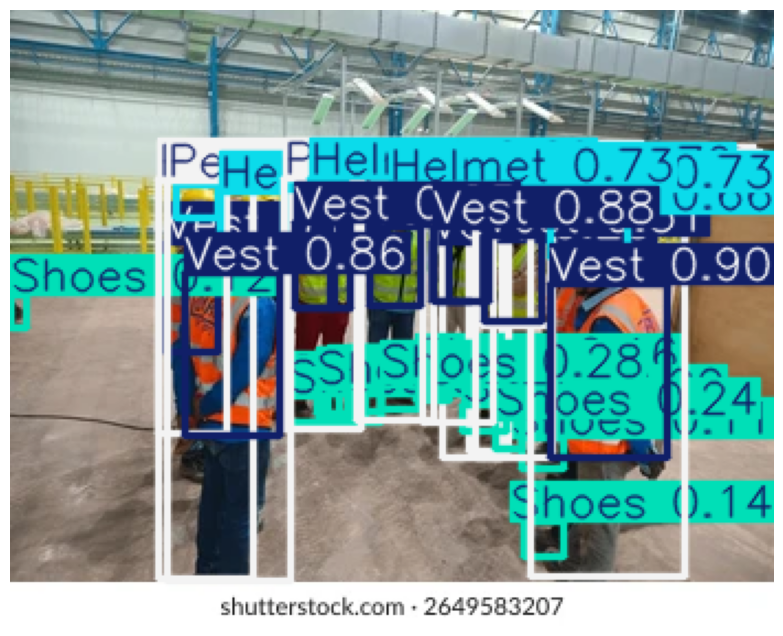

In [12]:
test_image_path = "/content/subang-18-march-2025-group-260nw-2649583207.webp"

results = model.predict(test_image_path, imgsz=640, conf=0.05)

for r in results:

    annotated_frame = r.plot()
    plt.figure(figsize=(10,8))
    plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


image 1/1 /content/istockphoto-1309413036-612x612.jpg: 448x640 4 Helmets, 3 Persons, 1 Shoes, 51.7ms
Speed: 2.2ms preprocess, 51.7ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


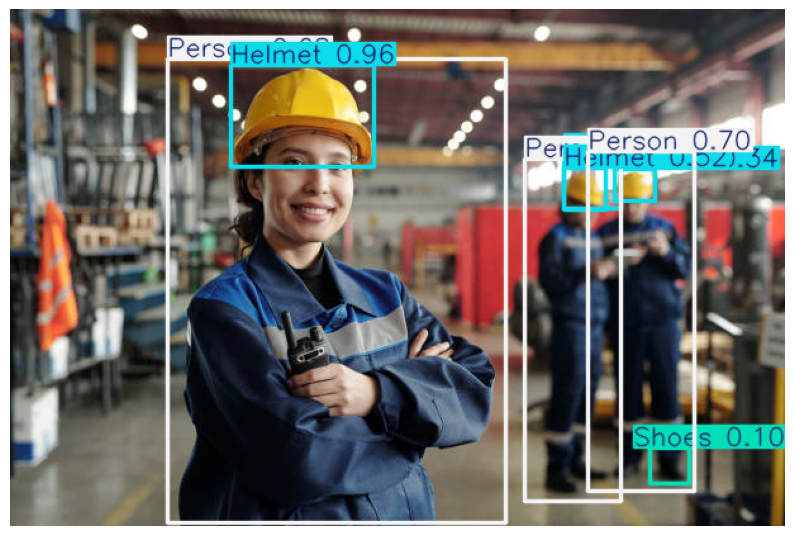

In [13]:
test_image_path = "/content/istockphoto-1309413036-612x612.jpg"

results = model.predict(test_image_path, imgsz=640, conf=0.1)

for r in results:

    annotated_frame = r.plot()
    plt.figure(figsize=(10,8))
    plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


image 1/1 /content/istockphoto-1309413036-612x612.jpg: 448x640 4 Helmets, 3 Persons, 1 Shoes, 1 Vest, 8.6ms
Speed: 2.0ms preprocess, 8.6ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


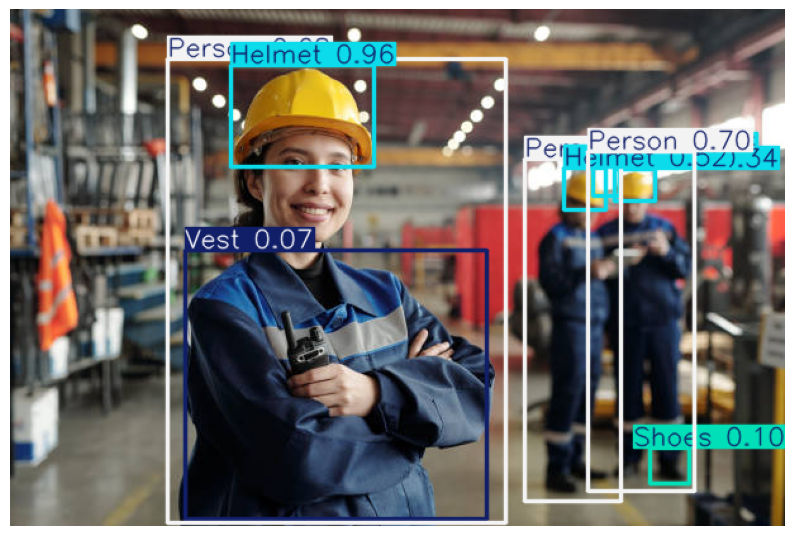

In [24]:
test_image_path = "/content/istockphoto-1309413036-612x612.jpg"
results = model.predict(
    source=test_image_path,
    imgsz=640,
    conf=0.06,
    iou=0.3
)


for r in results:
    annotated_frame = r.plot()
    plt.figure(figsize=(10,8))
    plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


image 1/1 /content/istockphoto-1299734004-612x612.jpg: 384x640 5 Helmets, 6 Persons, 3 Vests, 52.6ms
Speed: 3.3ms preprocess, 52.6ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


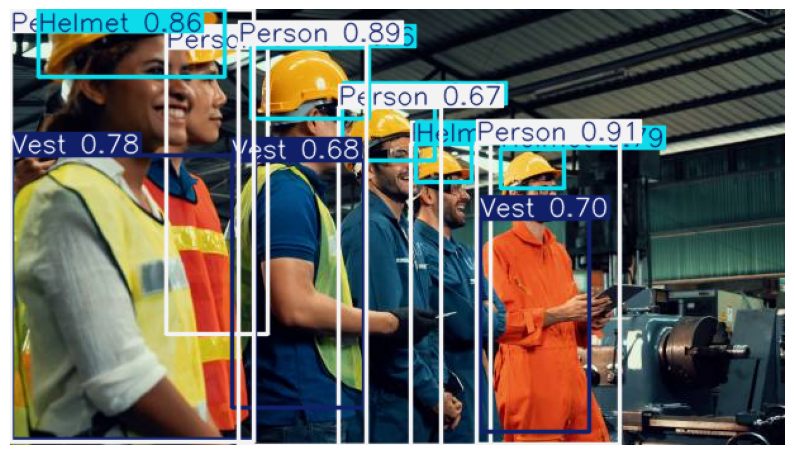

In [15]:
test_image_path = "/content/istockphoto-1299734004-612x612.jpg"

results = model.predict(test_image_path, imgsz=640, conf=0.25)

for r in results:

    annotated_frame = r.plot()
    plt.figure(figsize=(10,8))
    plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


image 1/1 /content/full-body-portrait-image-black-260nw-2686272785.webp: 640x608 2 Glovess, 1 Helmet, 1 Person, 2 Shoess, 1 Vest, 8.5ms
Speed: 2.0ms preprocess, 8.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 608)


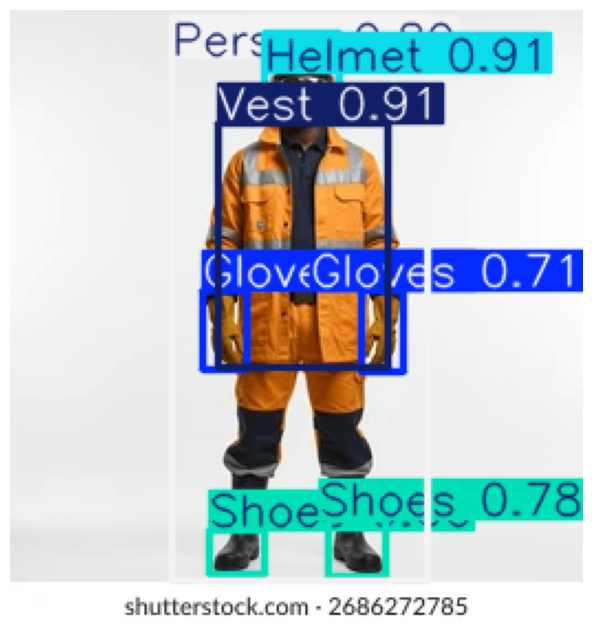

In [19]:
model = YOLO("/content/runs/detect/ppe_yolo11_aug/weights/best.pt")

test_image_path = "/content/full-body-portrait-image-black-260nw-2686272785.webp"

results = model.predict(test_image_path, imgsz=640, conf=0.10)

for r in results:
    annotated_frame = r.plot()
    plt.figure(figsize=(10,8))
    plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
